# Renewable Energy World Wide — Exploratory Data Analysis

**Dataset:** Renewable Share of Energy  
**Period:** 1965–2022

This notebook performs exploratory data analysis to understand changes in the share of renewable energy in equivalent primary energy across entities and over time.

### Analysis covered
- Dataset structure and data quality
- Missing values and duplicates
- Descriptive statistics
- Distribution of renewable-energy share
- Renewable-energy trend over time
- Entity-wise comparison
- Selected-year distributions
- Year-wise changes
- Highest/lowest observations
- Correlation analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("01 renewable-share-energy.csv")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (5603, 4)


,Entity,Code,Year,Renewables (% equivalent primary energy)
0,Africa,NaN,1965,5.747495
1,Africa,NaN,1966,6.122062
2,Africa,NaN,1967,6.325731
3,Africa,NaN,1968,7.005293
4,Africa,NaN,1969,7.956088


## 1. Dataset Structure and Data Quality

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate Rows:", df.duplicated().sum())


Columns:
['Entity', 'Code', 'Year', 'Renewables (% equivalent primary energy)']

Data Types:


,dtype
Entity,str
Code,str
Year,int64
Renewables (% equivalent primary energy),float64



Missing Values:


,missing_values
Entity,0
Code,1311
Year,0
Renewables (% equivalent primary energy),0



Duplicate Rows: 0


## 2. Descriptive Statistics

In [3]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Entity,5603,104,Africa,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code,4292,81,DZA,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5603.0,NaN,NaN,NaN,1993.800821,16.283556,1965.0,1980.0,1994.0,2008.0,2021.0
Renewables (% equivalent primary energy),5603.0,NaN,NaN,NaN,10.735585,12.923945,0.0,1.980135,6.522184,14.099622,86.874535


## 3. Distribution of Renewable Energy Share

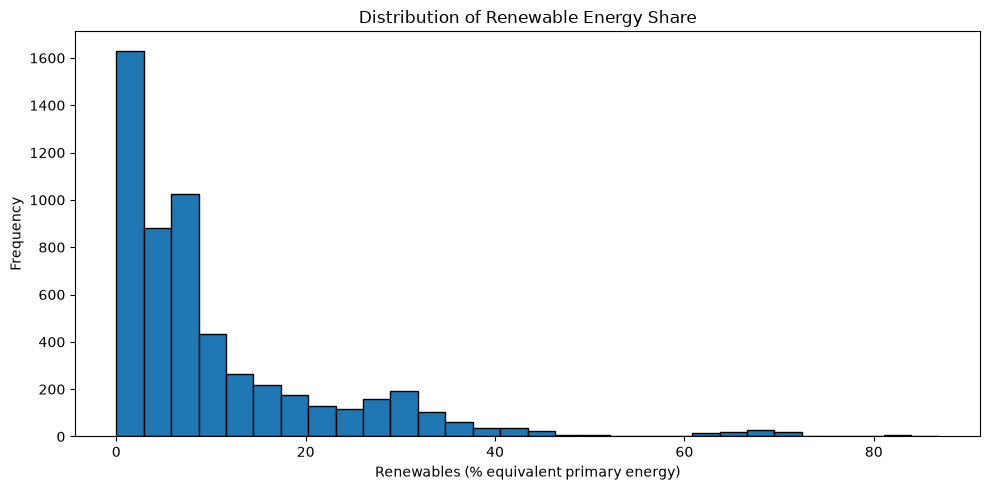

In [4]:
value_col = "Renewables (% equivalent primary energy)"

plt.figure(figsize=(10, 5))
plt.hist(df[value_col].dropna(), bins=30, edgecolor="black")
plt.xlabel("Renewables (% equivalent primary energy)")
plt.ylabel("Frequency")
plt.title("Distribution of Renewable Energy Share")
plt.tight_layout()
plt.show()


## 4. Renewable Energy Share Over Time

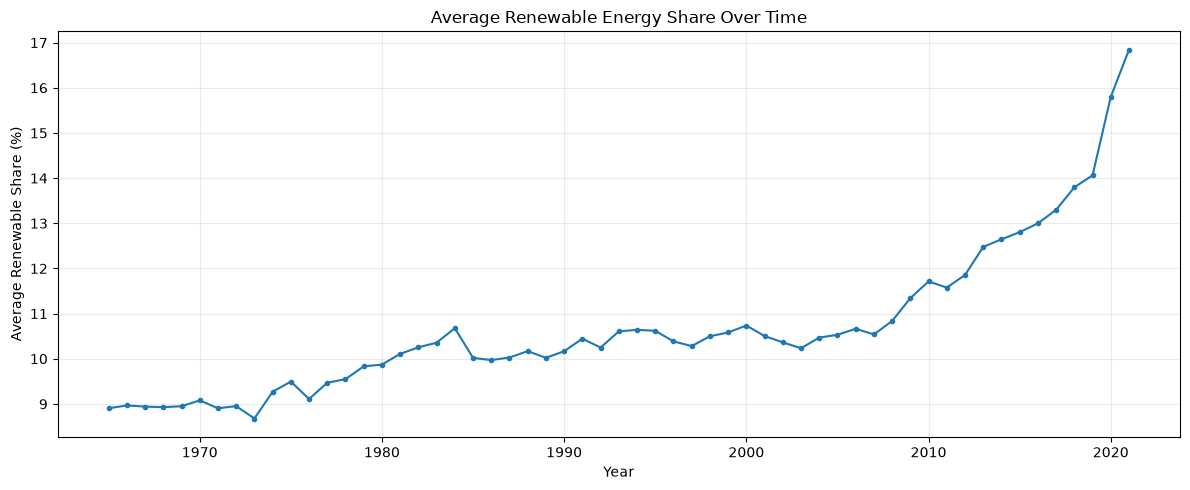

In [5]:
year_avg = df.groupby("Year")[value_col].mean()

plt.figure(figsize=(12, 5))
plt.plot(year_avg.index, year_avg.values, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("Average Renewable Share (%)")
plt.title("Average Renewable Energy Share Over Time")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Histogram Bin Experiments

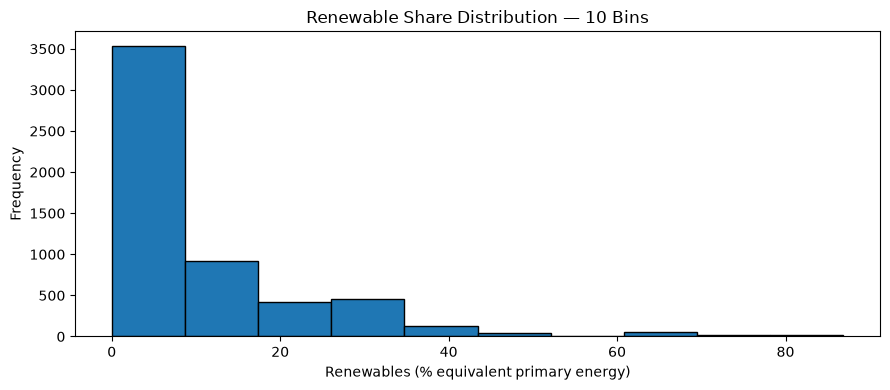

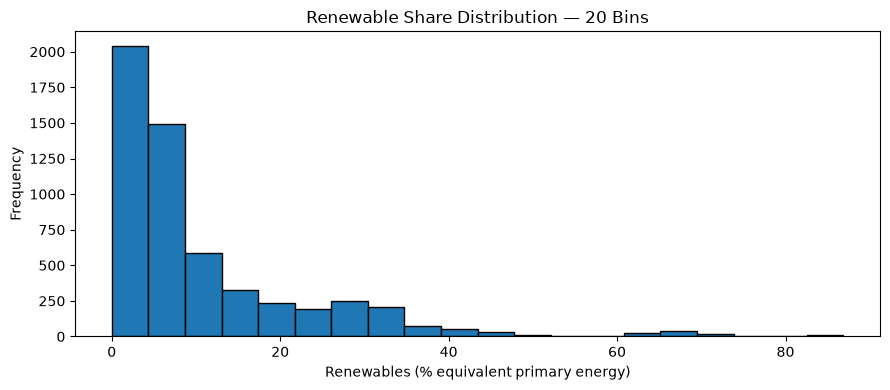

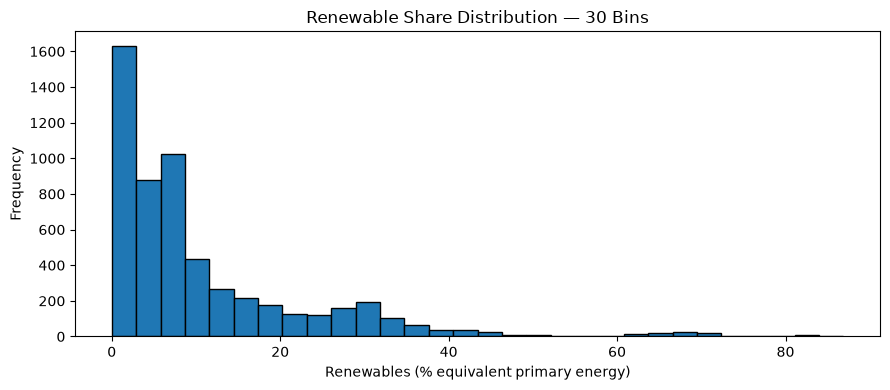

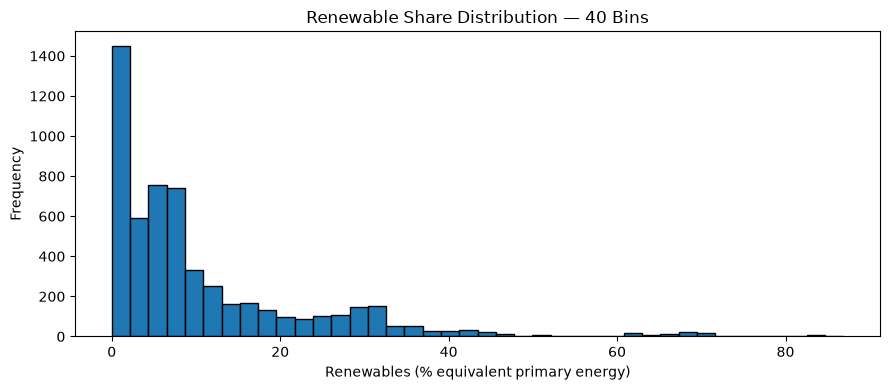

In [6]:
for bins in [10, 20, 30, 40]:
    plt.figure(figsize=(9, 4))
    plt.hist(df[value_col].dropna(), bins=bins, edgecolor="black")
    plt.xlabel("Renewables (% equivalent primary energy)")
    plt.ylabel("Frequency")
    plt.title(f"Renewable Share Distribution — {bins} Bins")
    plt.tight_layout()
    plt.show()


## 6. Selected Entities Over Time

Entities plotted: ['World', 'Asia', 'Europe', 'Africa', 'North America', 'South America', 'Oceania']


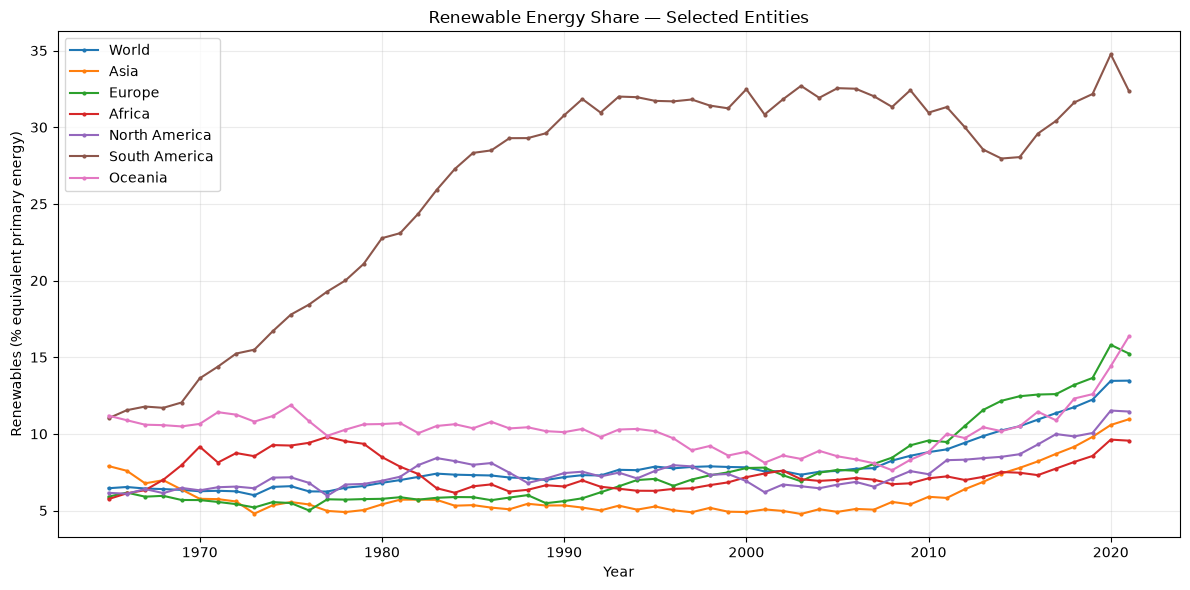

In [7]:
preferred = ["World", "Asia", "Europe", "Africa", "North America", "South America", "Oceania"]
available = [x for x in preferred if x in df["Entity"].unique()]

if not available:
    available = df["Entity"].value_counts().head(6).index.tolist()

print("Entities plotted:", available)

plt.figure(figsize=(12, 6))
for entity in available:
    temp = df[df["Entity"] == entity].sort_values("Year")
    plt.plot(temp["Year"], temp[value_col], marker="o", markersize=2, label=entity)

plt.xlabel("Year")
plt.ylabel("Renewables (% equivalent primary energy)")
plt.title("Renewable Energy Share — Selected Entities")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Entity-wise Average Renewable Share

,mean,min,max,count
Entity,,,,
Norway,68.019189,61.510117,72.447740,57
Iceland,62.063700,23.200014,86.874535,57
New Zealand,39.511652,32.730766,47.395737,57
Brazil,39.212813,25.056220,49.471880,57
Sweden,33.970861,25.265974,51.058970,57
Switzerland,31.674855,26.049185,42.143433,57
Middle Africa (BP),30.228478,20.706050,37.594368,57
Austria,29.462374,19.524147,38.260670,57
Eastern Africa (BP),28.633422,16.524014,36.039726,57


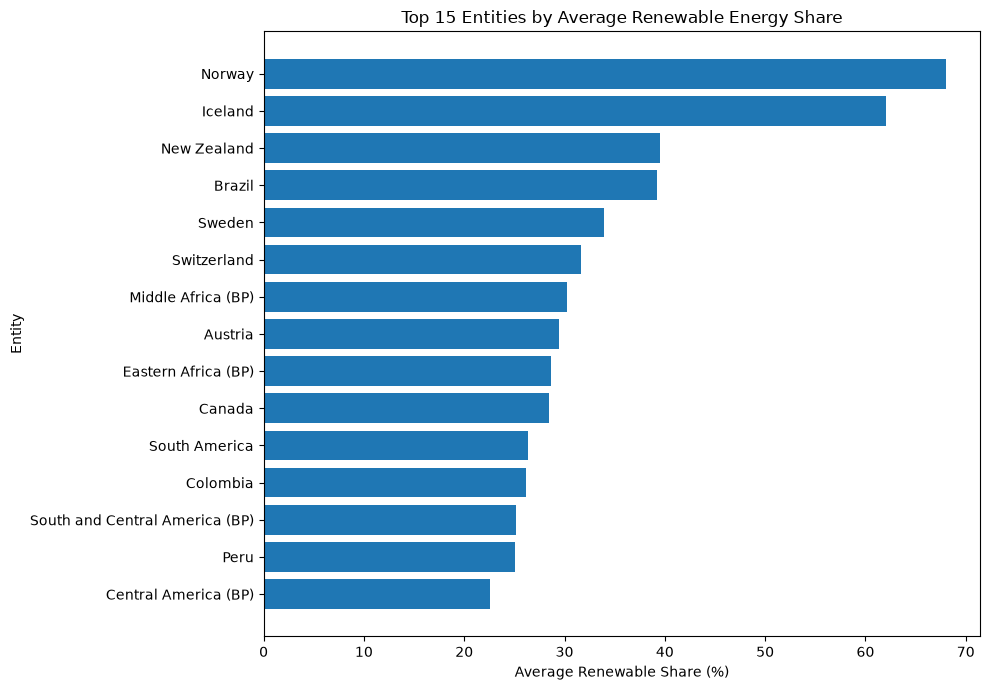

In [8]:
entity_avg = (
    df.groupby("Entity")[value_col]
      .agg(["mean", "min", "max", "count"])
      .sort_values("mean", ascending=False)
)

display(entity_avg.head(15))

top_entities = entity_avg.head(15).sort_values("mean")

plt.figure(figsize=(10, 7))
plt.barh(top_entities.index, top_entities["mean"])
plt.xlabel("Average Renewable Share (%)")
plt.ylabel("Entity")
plt.title("Top 15 Entities by Average Renewable Energy Share")
plt.tight_layout()
plt.show()


## 8. Renewable Share in Selected Years

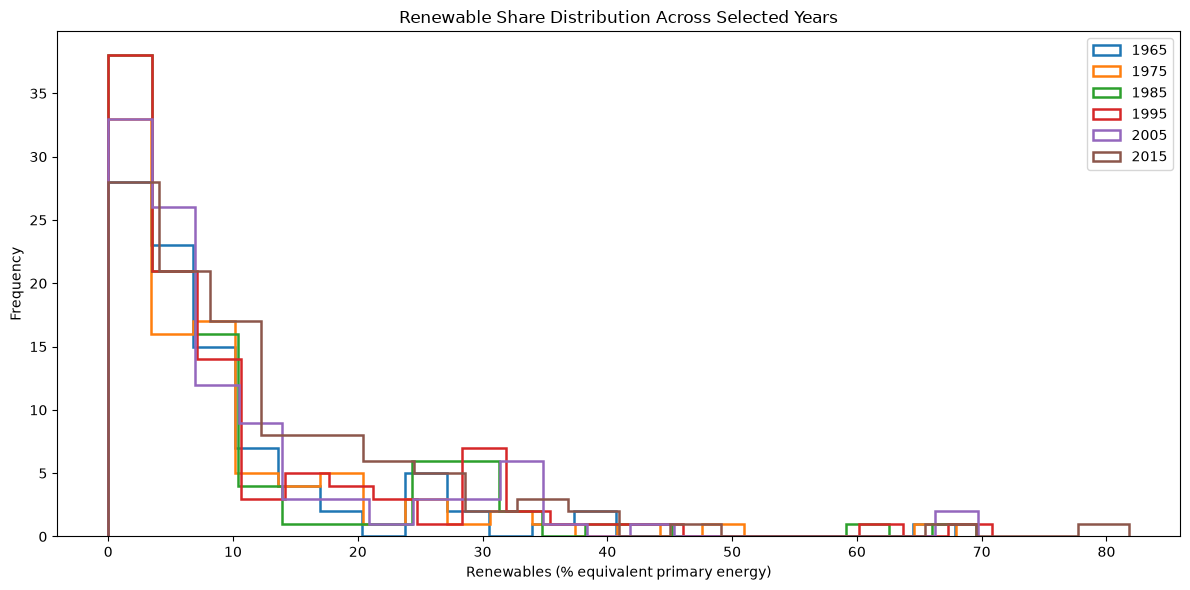

In [9]:
selected_years = [1965, 1975, 1985, 1995, 2005, 2015, 2022]
available_years = [y for y in selected_years if y in df["Year"].unique()]

year_entity = df[df["Year"].isin(available_years)]

plt.figure(figsize=(12, 6))
for year in available_years:
    vals = year_entity.loc[year_entity["Year"] == year, value_col].dropna()
    plt.hist(vals, bins=20, histtype="step", linewidth=1.8, label=str(year))

plt.xlabel("Renewables (% equivalent primary energy)")
plt.ylabel("Frequency")
plt.title("Renewable Share Distribution Across Selected Years")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Year-wise Change in Average Renewable Share

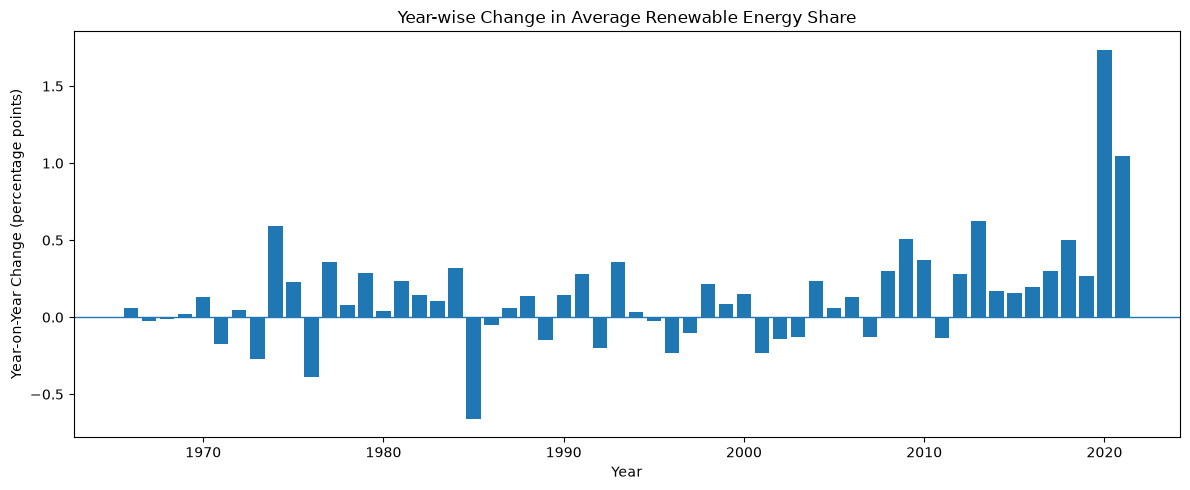

,change
Year,
2020,1.735839
2021,1.044458
2013,0.623131
1974,0.592029
2009,0.505333
2018,0.498292
2010,0.370295
1977,0.360025
1993,0.358563


In [10]:
year_change = year_avg.diff()

plt.figure(figsize=(12, 5))
plt.bar(year_change.index, year_change.values)
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("Year-on-Year Change (percentage points)")
plt.title("Year-wise Change in Average Renewable Energy Share")
plt.tight_layout()
plt.show()

display(
    year_change.dropna()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("change")
)


## 10. Highest and Lowest Recorded Renewable Shares

In [11]:
highest = df.loc[df[value_col].idxmax(), ["Entity", "Code", "Year", value_col]]
lowest = df.loc[df[value_col].idxmin(), ["Entity", "Code", "Year", value_col]]

print("Highest recorded value:")
display(highest.to_frame("value"))

print("Lowest recorded value:")
display(lowest.to_frame("value"))


Highest recorded value:


,value
Entity,Iceland
Code,ISL
Year,2021
Renewables (% equivalent primary energy),86.874535


Lowest recorded value:


,value
Entity,Cyprus
Code,CYP
Year,1965
Renewables (% equivalent primary energy),0.0


## 11. Correlation Analysis

,Year,Renewables (% equivalent primary energy)
Year,1.000000,0.108083
Renewables (% equivalent primary energy),0.108083,1.000000


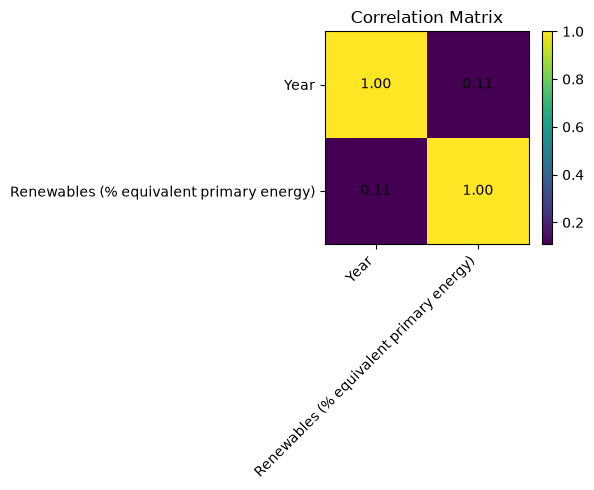

In [12]:
numeric_cols = ["Year", value_col]
corr = df[numeric_cols].corr()

display(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## 12. Final EDA Summary

Use the generated tables and plots to discuss:
- how renewable-energy share changes across 1965–2022,
- how distributions differ across selected years,
- which entities have higher or lower average renewable shares,
- years with larger increases or decreases,
- and the highest/lowest recorded observations.

**Note:** This is an EDA notebook; it does not train a machine-learning model or produce prediction metrics.
